--- Phase 3 (REVISED): In-Depth Intersectional EDA ---
Successfully loaded 'MASTER_feature_engineered.csv'. Shape: (100875, 80)
Generating Plot 1: Language Category by Product Category...
...Saved 'plot_1_language_by_product.png'
Generating Plot 2: Language Use by Subreddit...
...Saved 'plot_2_language_by_subreddit.png'
Generating Plot 3: Narratives by Product Type...
...Saved 'plot_3_narrative_by_product.png'
Generating Plot 4: Narratives by Language Type...
...Saved 'plot_4_narrative_by_language.png'
Generating Plot 5: Trends Over Time...


C:\Users\chauh\AppData\Local\Temp\ipykernel_10120\1528337380.py:166: UserWarning: Parsing dates in %Y-%m-%d %H:%M:%S format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df['datetime'] = pd.to_datetime(df['datetime'], dayfirst=True, errors='coerce')


...Saved 'plot_5_temporal_trends.png'

--- Phase 3 (REVISED) Complete ---
Generated 5 key analysis plots. Please review them and we can proceed.


<Figure size 1400x800 with 0 Axes>

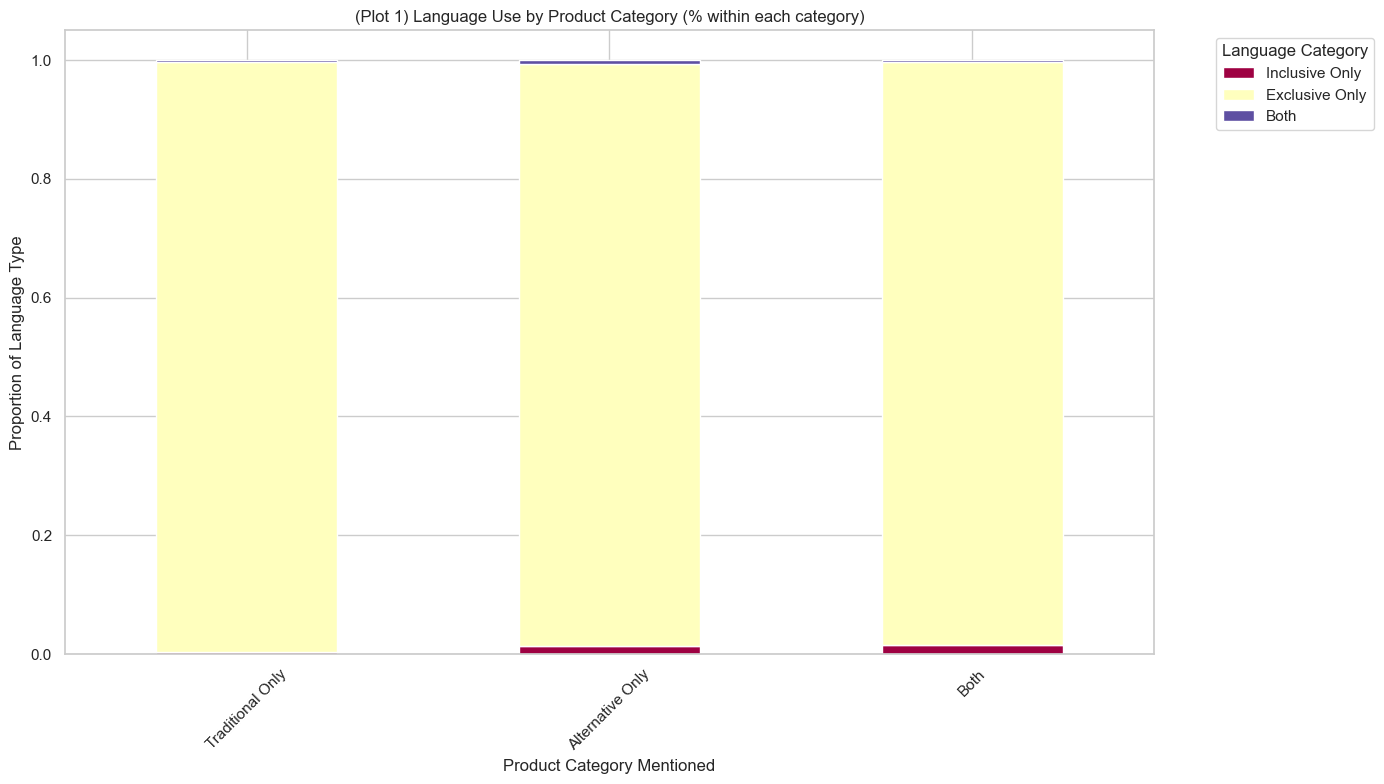

<Figure size 1400x1000 with 0 Axes>

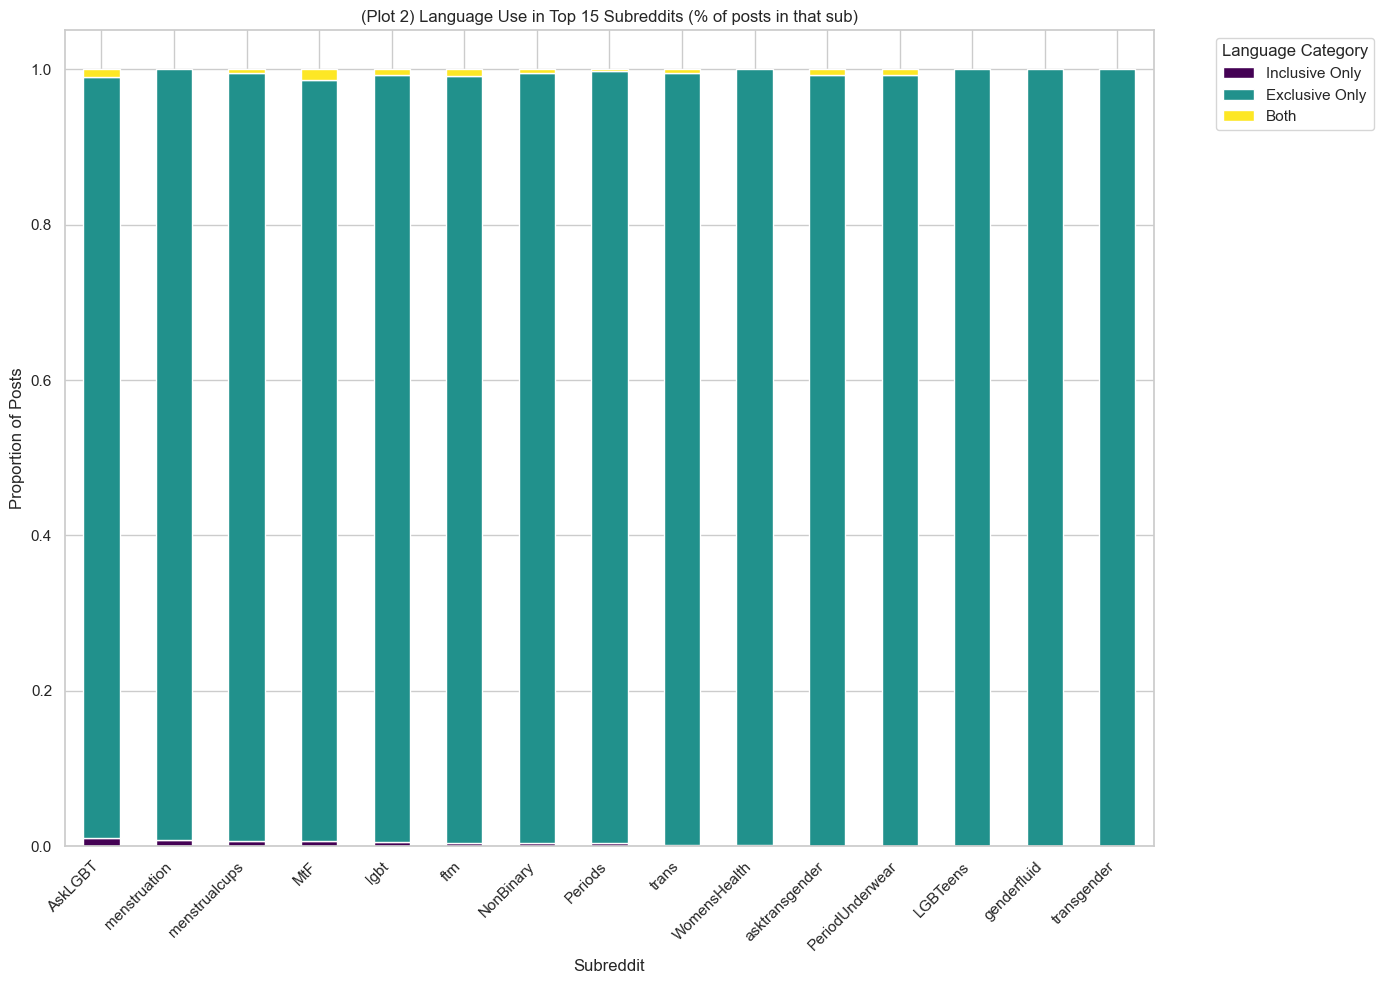

<Figure size 1400x800 with 0 Axes>

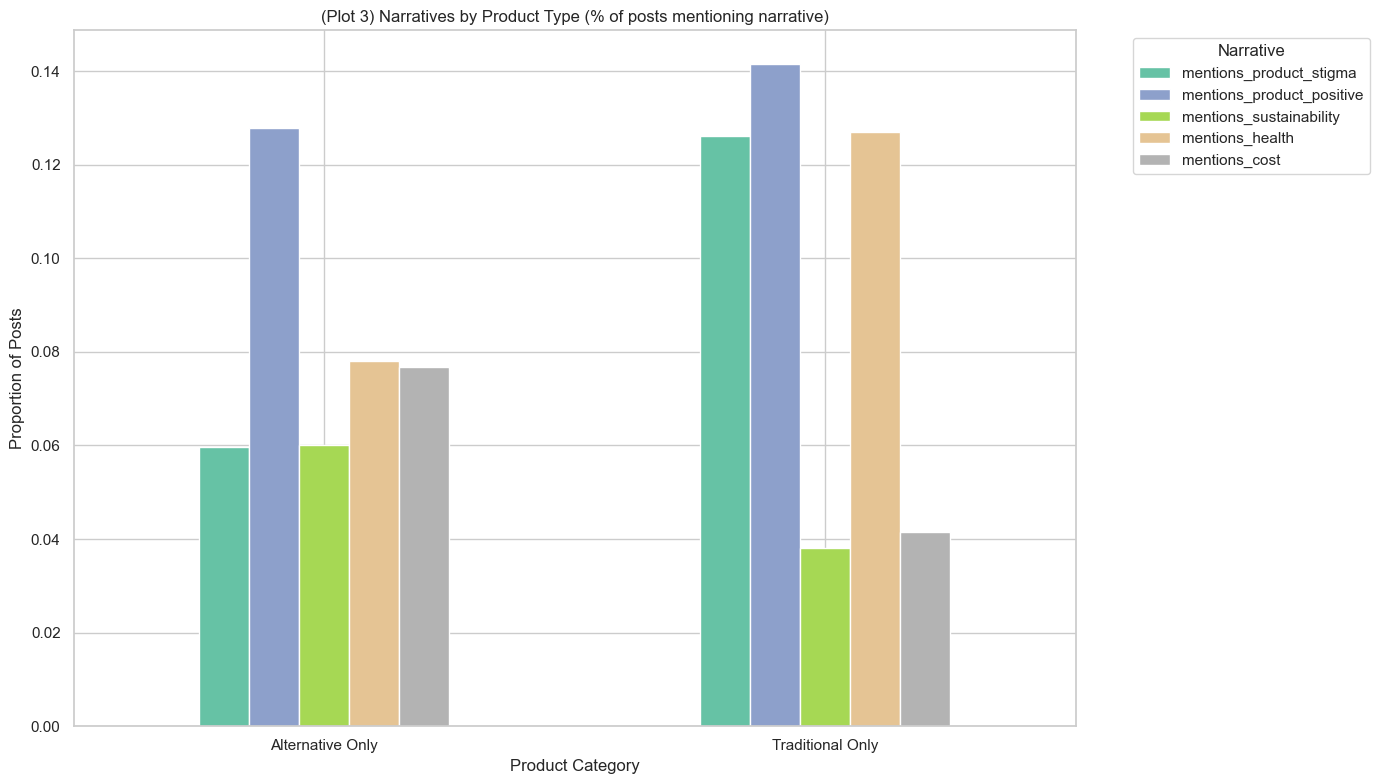

<Figure size 1200x700 with 0 Axes>

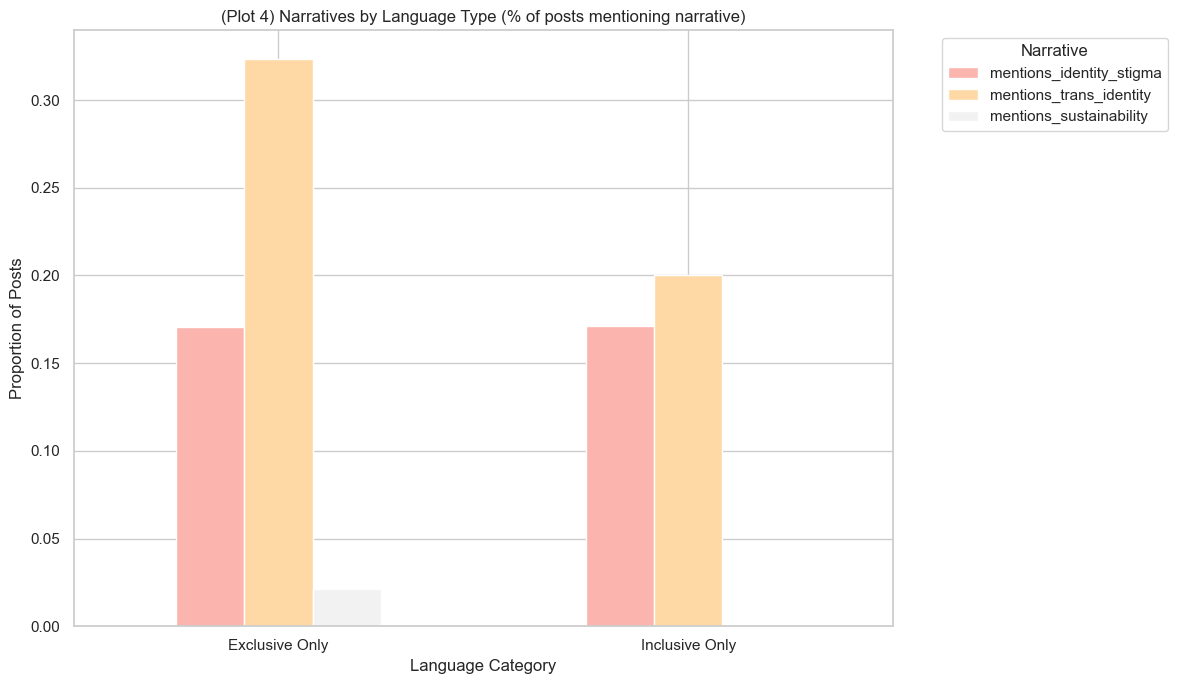

<Figure size 1500x1000 with 0 Axes>

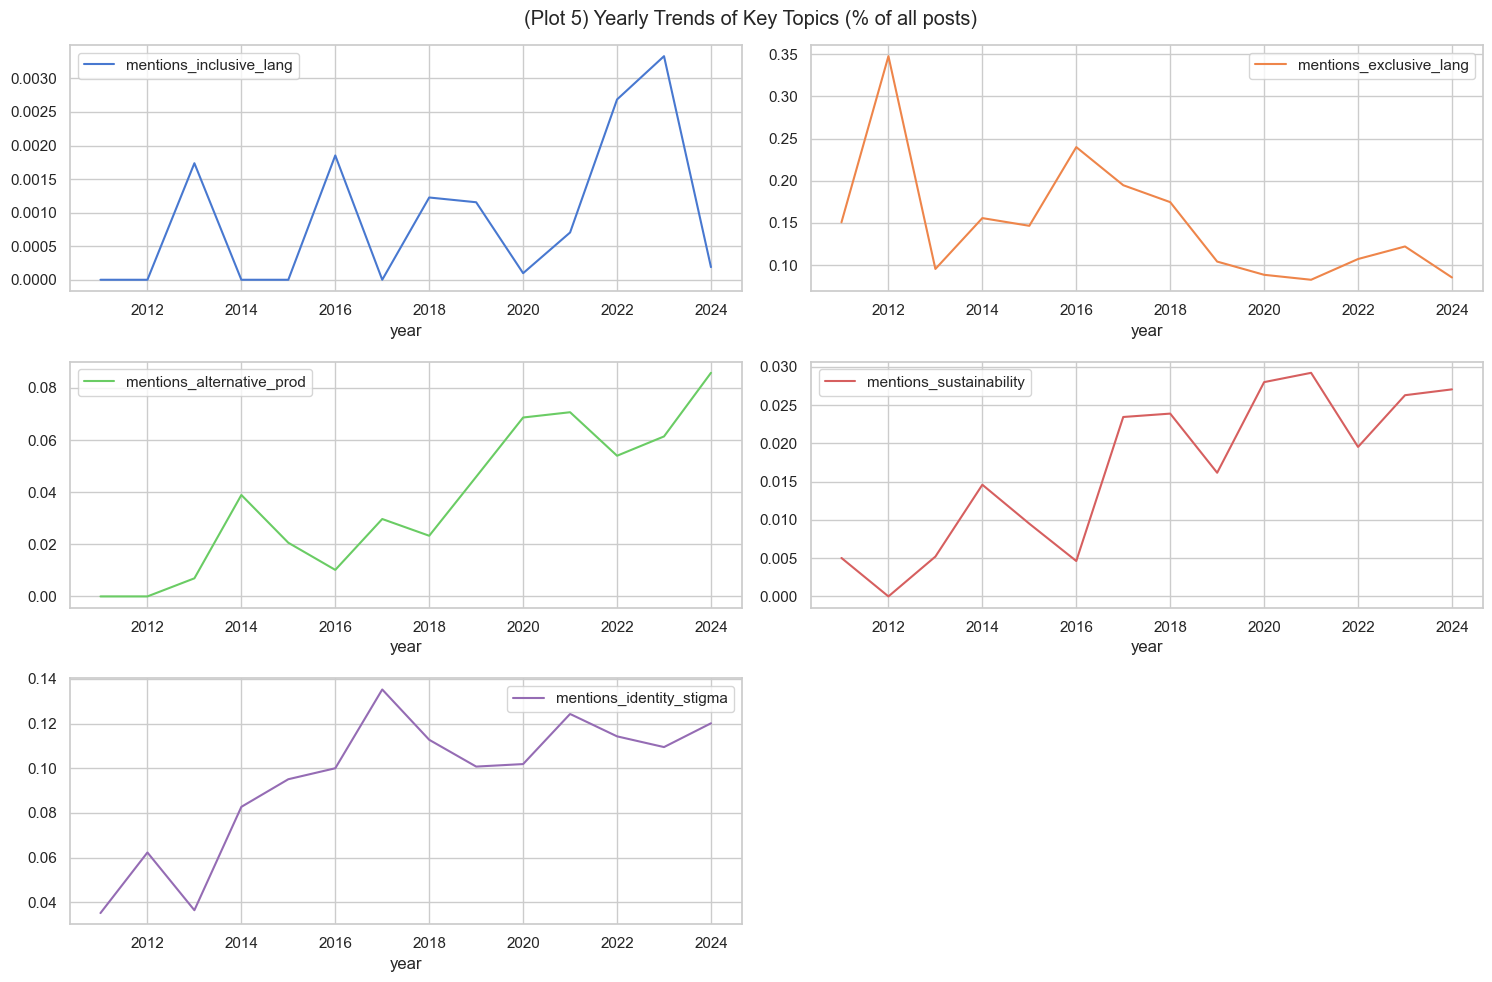

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Phase 3 (REVISED): In-Depth Intersectional EDA ---")

try:
    # 1. Load the feature-engineered dataset from Phase 2
    df = pd.read_csv("MASTER_feature_engineered.csv")
    print(f"Successfully loaded 'MASTER_feature_engineered.csv'. Shape: {df.shape}")

    # Set up plotting style
    sns.set_theme(style="whitegrid", palette="muted")
    
    # --- 1. The Core Intersectional Question: Language vs. Products ---
    print("Generating Plot 1: Language Category by Product Category...")
    
    ct_lang_prod = pd.crosstab(
        df['product_category'], 
        df['language_category'], 
        normalize='index' # This gives us the % within each product category
    )
    
    # --- ROBUST RE-INDEXING (THE FIX) ---
    # Define our desired order
    desired_index_order = ['Traditional Only', 'Alternative Only', 'Both', 'None']
    desired_column_order = ['Inclusive Only', 'Exclusive Only', 'Both', 'None']
    
    # Find which of our desired categories *actually exist* in the crosstab
    present_index = [cat for cat in desired_index_order if cat in ct_lang_prod.index]
    present_columns = [cat for cat in desired_column_order if cat in ct_lang_prod.columns]
    
    # Re-index *only* with the categories that are present
    ct_lang_prod = ct_lang_prod.reindex(index=present_index, columns=present_columns)
    # --- END FIX ---

    # Plot
    plt.figure(figsize=(14, 8))
    ct_lang_prod.plot(
        kind='bar', 
        stacked=True, 
        figsize=(14, 8), 
        cmap='Spectral',
        title='(Plot 1) Language Use by Product Category (% within each category)'
    )
    plt.ylabel('Proportion of Language Type')
    plt.xlabel('Product Category Mentioned')
    plt.xticks(rotation=45)
    plt.legend(title='Language Category', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('plot_1_language_by_product.png')
    print("...Saved 'plot_1_language_by_product.png'")


    # --- 2. Community Analysis: Where is this language used? ---
    print("Generating Plot 2: Language Use by Subreddit...")
    top_15_subreddits = df['subreddit'].value_counts().head(15).index.tolist()
    df_top15 = df[df['subreddit'].isin(top_15_subreddits)]

    lang_by_sub = pd.crosstab(
        df_top15['subreddit'],
        df_top15['language_category'],
        normalize='index' # % within each subreddit
    )
    
    # Sort by 'Inclusive Only' to see which subs are most inclusive
    # We need to make sure 'Inclusive Only' column exists before sorting
    if 'Inclusive Only' in lang_by_sub.columns:
        lang_by_sub = lang_by_sub.sort_values(by='Inclusive Only', ascending=False)
    
    # --- ROBUST RE-INDEXING (THE FIX) ---
    # We only care about the rare, important categories
    desired_plot_cols = ['Inclusive Only', 'Exclusive Only', 'Both']
    present_plot_cols = [col for col in desired_plot_cols if col in lang_by_sub.columns]
    
    # Only try to plot the columns that actually exist
    if present_plot_cols:
        lang_by_sub_plot = lang_by_sub[present_plot_cols]

        plt.figure(figsize=(14, 10))
        lang_by_sub_plot.plot(
            kind='bar', 
            stacked=True, 
            figsize=(14, 10), 
            cmap='viridis',
            title='(Plot 2) Language Use in Top 15 Subreddits (% of posts in that sub)'
        )
        plt.ylabel('Proportion of Posts')
        plt.xlabel('Subreddit')
        plt.xticks(rotation=45, ha='right')
        plt.legend(title='Language Category', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.savefig('plot_2_language_by_subreddit.png')
        print("...Saved 'plot_2_language_by_subreddit.png'")
    else:
        print("...Skipped Plot 2: No relevant language categories found for plotting.")


    # --- 3. Narrative Analysis: Stigma, Positives, and Sustainability ---
    print("Generating Plot 3: Narratives by Product Type...")
    
    df_prod_filtered = df[df['product_category'].isin(['Traditional Only', 'Alternative Only'])]
    
    if not df_prod_filtered.empty:
        narrative_by_prod = df_prod_filtered.groupby('product_category')[[
            'mentions_product_stigma',
            'mentions_product_positive',
            'mentions_sustainability',
            'mentions_health',
            'mentions_cost'
        ]].mean() # .mean() on a 0/1 column gives the %

        plt.figure(figsize=(14, 8))
        narrative_by_prod.plot(
            kind='bar',
            figsize=(14, 8),
            cmap='Set2',
            title='(Plot 3) Narratives by Product Type (% of posts mentioning narrative)'
        )
        plt.ylabel('Proportion of Posts')
        plt.xlabel('Product Category')
        plt.xticks(rotation=0)
        plt.legend(title='Narrative', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.savefig('plot_3_narrative_by_product.png')
        print("...Saved 'plot_3_narrative_by_product.png'")
    else:
        print("...Skipped Plot 3: No posts found filtering for 'Traditional Only' or 'Alternative Only'.")


    # --- 4. Narrative Analysis: Identity & Language ---
    print("Generating Plot 4: Narratives by Language Type...")
    
    df_lang_filtered = df[df['language_category'].isin(['Inclusive Only', 'Exclusive Only'])]
    
    if not df_lang_filtered.empty:
        narrative_by_lang = df_lang_filtered.groupby('language_category')[[
            'mentions_identity_stigma',
            'mentions_trans_identity',
            'mentions_sustainability'
        ]].mean()

        plt.figure(figsize=(12, 7))
        narrative_by_lang.plot(
            kind='bar',
            figsize=(12, 7),
            cmap='Pastel1',
            title='(Plot 4) Narratives by Language Type (% of posts mentioning narrative)'
        )
        plt.ylabel('Proportion of Posts')
        plt.xlabel('Language Category')
        plt.xticks(rotation=0)
        plt.legend(title='Narrative', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.savefig('plot_4_narrative_by_language.png')
        print("...Saved 'plot_4_narrative_by_language.png'")
    else:
        print("...Skipped Plot 4: No posts found filtering for 'Inclusive Only' or 'Exclusive Only'.")

    # --- 5. Temporal Analysis: Change Over Time ---
    print("Generating Plot 5: Trends Over Time...")
    
    try:
        # Use dayfirst=True to correctly parse '13-04-2023' format
        df['datetime'] = pd.to_datetime(df['datetime'], dayfirst=True, errors='coerce')
        df['year'] = df['datetime'].dt.year
        
        # Filter out NaT (Not a Time) from failed conversions and future dates
        df_time = df.dropna(subset=['year'])
        df_time = df_time[df_time['year'] < 2025] # 2025 is incomplete
        df_time = df_time[df_time['year'] > 2010] # Filter out potential bad data

        if not df_time.empty:
            time_trends = df_time.groupby('year')[[
                'mentions_inclusive_lang',
                'mentions_exclusive_lang',
                'mentions_alternative_prod',
                'mentions_sustainability',
                'mentions_identity_stigma'
            ]].mean()

            plt.figure(figsize=(15, 10))
            time_trends.plot(
                figsize=(15, 10),
                subplots=True,
                layout=(3, 2),
                title='(Plot 5) Yearly Trends of Key Topics (% of all posts)',
                sharex=False
            )
            plt.xlabel('Year')
            plt.tight_layout()
            plt.savefig('plot_5_temporal_trends.png')
            print("...Saved 'plot_5_temporal_trends.png'")
        else:
            print("...Skipped Plot 5: No valid time data found after filtering.")

    except Exception as e:
        print(f"An error occurred during time analysis (Plot 5): {e}")
    
    print("\n--- Phase 3 (REVISED) Complete ---")
    print("Generated 5 key analysis plots. Please review them and we can proceed.")

except FileNotFoundError:
    print("Error: Could not find 'MASTER_feature_engineered.csv'.")
    print("Please make sure the output from Phase 2 is in the same directory.")
except Exception as e:
    print(f"An error occurred: {e}")